# Deribit BTC Implied-Vol Surface in Python — with `candlefeed`

**The question every options trader starts with:** what does the BTC vol surface look like *right now* — is the market pricing fear into downside puts (skew), and is short-dated vol cheap or rich versus long-dated (term structure)? Answering it normally means an Amberdata/Tardis contract or scraping Deribit yourself. Here it's a few lines.

This notebook uses the official [CandleFeed](https://candlefeed.ai) client to pull the **Deribit BTC options chain** — every listed strike and expiry with its mark IV, greeks and open interest — and build:

1. The **volatility smile** for a single expiry (IV vs. strike) — the skew.
2. The **ATM term structure** (IV vs. time-to-expiry) — is the curve in contango?
3. A full **IV surface** (strike × expiry) as a heatmap.

> **Tier note:** Deribit options are a **Pro-tier** dataset — this is the notebook that shows what the paid tier buys you. IV/greeks/OI history is otherwise an enterprise purchase elsewhere; here it's `$99/mo`, self-serve.
>
> **Data note (honest framing):** the chain below is a real captured snapshot from **2026-05-28** (a burst of per-instrument captures within an ~8-minute window, which we collapse into one coherent as-of chain). It's a *cross-sectional* snapshot — the structure of the surface at a moment in time — not an IV time series.


In [1]:
# pip install candlefeed matplotlib pandas
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from candlefeed import CandleFeed

cf = CandleFeed()
print("Connected to CandleFeed:", cf.status()["status"])

Connected to CandleFeed: ok


## 1. Pull the chain and assemble a coherent snapshot

`get_options(currency="BTC")` returns chain snapshots with `strike`, `expiry`, `option_type`, `mark_iv`, greeks, `open_interest` and the `underlying_price` at capture. The capture comes as a burst of per-instrument rows over a few minutes; we take the **latest row per instrument** to assemble one clean, near-instantaneous chain, then compute moneyness (strike ÷ spot) and time-to-expiry.


In [2]:
raw = cf.get_options(currency="BTC", start="2026-05-28", end="2026-05-29", max_rows=8000)
print("rows pulled:", len(raw), "| capture window:",
      raw.index.min(), "->", raw.index.max())

# latest row per instrument => one coherent chain
chain = raw.sort_index().groupby("instrument_name").tail(1).reset_index()
chain["expiry_dt"] = pd.to_datetime(chain["expiry"], utc=True)
asof = raw.index.max()
chain["T_days"] = (chain["expiry_dt"] - asof.normalize()).dt.total_seconds() / 86400
chain["spot"] = chain["underlying_price"].fillna(chain["index_price"])
chain["moneyness"] = chain["strike"] / chain["spot"]

# keep live, sane quotes
chain = chain[(chain["T_days"] > 0) & chain["mark_iv"].notna() & (chain["mark_iv"] > 0)].copy()
spot = chain["spot"].median()
print(f"clean chain: {len(chain)} instruments | spot ~ ${spot:,.0f} | "
      f"{chain['expiry'].nunique()} expiries")
chain.groupby(chain["expiry_dt"].dt.date).size().rename("instruments").to_frame().head(12)

rows pulled: 8000 | capture window: 2026-05-28 04:33:35.773596+00:00 -> 2026-05-28 04:41:56.172647+00:00
clean chain: 844 instruments | spot ~ $73,220 | 10 expiries


,instruments
expiry_dt,
2026-05-29,110
2026-05-30,58
2026-05-31,58
2026-06-05,44
2026-06-12,42
2026-06-26,118
2026-07-31,92
2026-09-25,116
2026-12-25,114


## 2. The volatility smile (skew) for one expiry

Deribit reports a single mark IV per strike (shared by the call and put), so we dedupe by strike. Plotting IV against moneyness for a ~1-month expiry shows the classic BTC **smile/smirk**: IV is lowest near the money and rises into both wings, with the downside (puts, moneyness < 1) typically bid relative to the equivalent upside — the market paying up for crash protection.


IV @0.90 (downside): 41.2%   IV @1.00 (ATM): 35.5%   IV @1.10 (upside): 34.0%
25%-wing skew (0.90 minus 1.10): +7.2 vol points


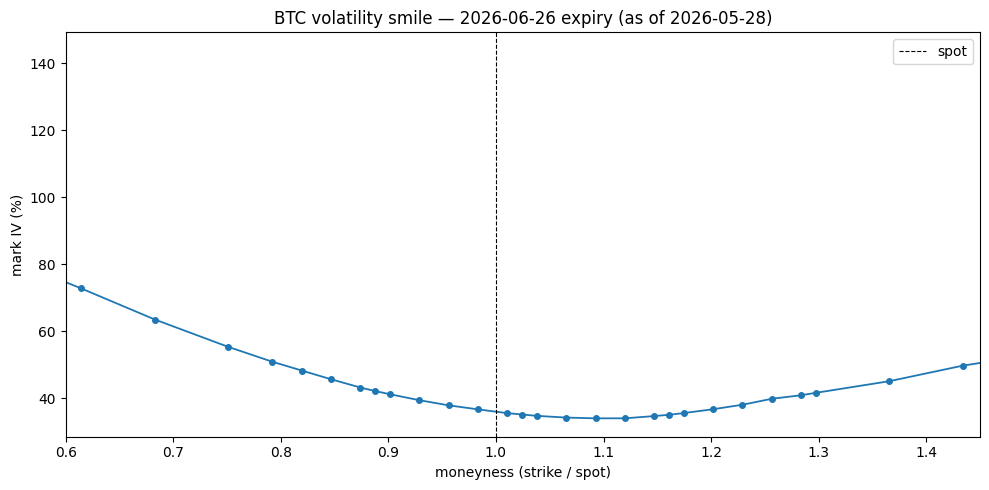

In [3]:
def smile(exp):
    s = (chain[chain["expiry"] == exp]
         .drop_duplicates("strike").sort_values("moneyness"))
    return s

EXPIRY = "2026-06-26"   # ~1 month out
s = smile(EXPIRY)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(s["moneyness"], s["mark_iv"], marker="o", ms=4, lw=1.3, color="C0")
ax.axvline(1.0, color="k", ls="--", lw=0.8, label="spot")
ax.set_xlim(0.6, 1.45)
ax.set_xlabel("moneyness (strike / spot)"); ax.set_ylabel("mark IV (%)")
ax.set_title(f"BTC volatility smile — {EXPIRY} expiry (as of {asof:%Y-%m-%d})")
ax.legend(); plt.tight_layout()

# quantify the skew: IV of 0.90-moneyness put-wing vs 1.10-moneyness call-wing
def iv_at(s, m):
    return s.iloc[(s["moneyness"] - m).abs().argmin()]["mark_iv"]
dn, atm, up = iv_at(s, 0.90), iv_at(s, 1.00), iv_at(s, 1.10)
print(f"IV @0.90 (downside): {dn:.1f}%   IV @1.00 (ATM): {atm:.1f}%   IV @1.10 (upside): {up:.1f}%")
print(f"25%-wing skew (0.90 minus 1.10): {dn - up:+.1f} vol points")

## 3. ATM term structure — is vol in contango?

Taking the near-ATM IV for each expiry and plotting it against time-to-expiry shows the **term structure**: short-dated vol versus long-dated. An upward-sloping (contango) curve means the market prices more uncertainty further out — the normal calm-market shape; an inverted curve flags near-term stress.


 T_days  atm_iv     expiry
    1.0   39.18 2026-05-29
    2.0   38.78 2026-05-30
    3.0   34.00 2026-05-31
    8.0   35.84 2026-06-05
   15.0   35.90 2026-06-12
   29.0   35.51 2026-06-26
   64.0   36.82 2026-07-31
  120.0   38.88 2026-09-25
  211.0   42.87 2026-12-25
  302.0   44.07 2027-03-26

Front (1d) to back (302d) ATM IV move: +4.9 vol points (contango)


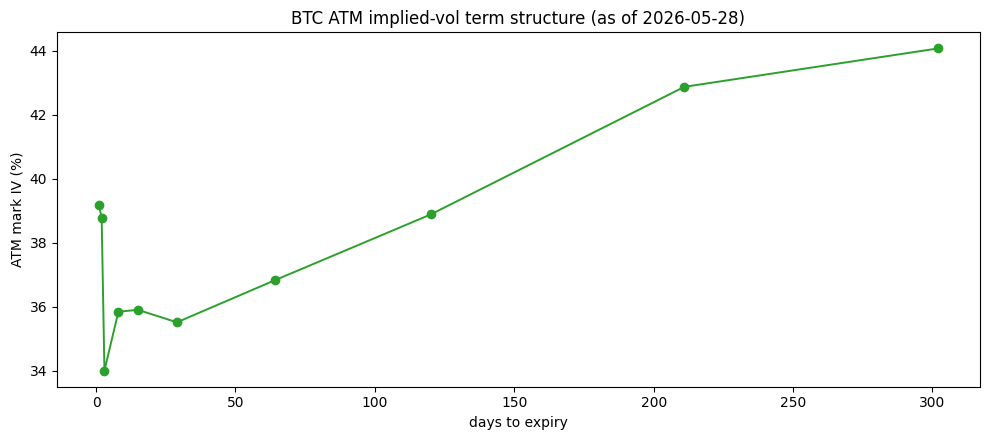

In [4]:
rows = []
for exp, g in chain.groupby("expiry"):
    g = g.drop_duplicates("strike").copy()
    atm_row = g.iloc[(g["moneyness"] - 1.0).abs().argmin()]
    rows.append((atm_row["T_days"], atm_row["mark_iv"], exp))
term = pd.DataFrame(rows, columns=["T_days", "atm_iv", "expiry"]).sort_values("T_days")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(term["T_days"], term["atm_iv"], marker="o", lw=1.4, color="C2")
ax.set_xlabel("days to expiry"); ax.set_ylabel("ATM mark IV (%)")
ax.set_title(f"BTC ATM implied-vol term structure (as of {asof:%Y-%m-%d})")
plt.tight_layout()

print(term.assign(T_days=term["T_days"].round(0)).to_string(index=False))
slope = term["atm_iv"].iloc[-1] - term["atm_iv"].iloc[0]
print(f"\nFront ({term['T_days'].min():.0f}d) to back ({term['T_days'].max():.0f}d) ATM IV move: {slope:+.1f} vol points "
      f"({'contango' if slope > 0 else 'backwardation'})")

## 4. The full surface (strike × expiry)

Putting it together: bin every quote by moneyness and expiry and render the whole surface as a heatmap. The vertical gradient is the term structure; the horizontal gradient at each expiry is the smile. This single chart is the thing a vol desk stares at all day.


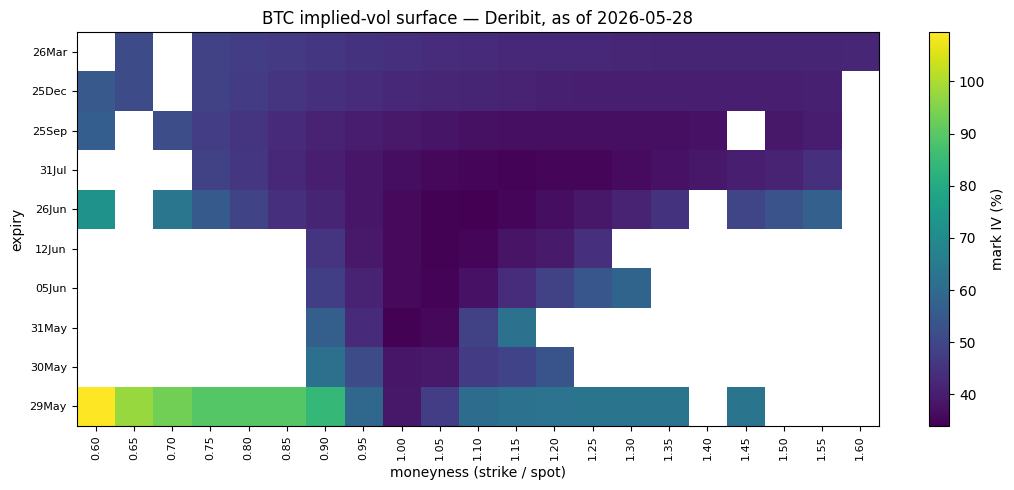

In [5]:
grid = chain[(chain["moneyness"] > 0.6) & (chain["moneyness"] < 1.6)].copy()
grid["mny_bin"] = (grid["moneyness"] / 0.05).round() * 0.05
grid["exp_lbl"] = grid["expiry_dt"].dt.strftime("%d%b")
surf = (grid.pivot_table(index="exp_lbl", columns="mny_bin", values="mark_iv", aggfunc="mean")
            .reindex(term.sort_values("T_days")["expiry"]
                     .map(lambda e: pd.to_datetime(e).strftime("%d%b"))))

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(surf.values, aspect="auto", cmap="viridis", origin="lower")
ax.set_xticks(range(len(surf.columns)))
ax.set_xticklabels([f"{c:.2f}" for c in surf.columns], rotation=90, fontsize=8)
ax.set_yticks(range(len(surf.index))); ax.set_yticklabels(surf.index, fontsize=8)
ax.set_xlabel("moneyness (strike / spot)"); ax.set_ylabel("expiry")
ax.set_title(f"BTC implied-vol surface — Deribit, as of {asof:%Y-%m-%d}")
fig.colorbar(im, ax=ax, label="mark IV (%)")
plt.tight_layout()

## What you just built — and the honest caveats

In ~30 lines you reconstructed the three views a crypto-vol trader actually uses: the **smile** (skew), the **term structure** (contango vs. backwardation), and the **full surface** — straight from a normalized API, on a clean pandas frame, no enterprise contract.

**Caveats, stated plainly:**

- **Snapshot, not a time series.** This is the surface at one moment (2026-05-28). To study how skew or term structure *evolves* — e.g. skew steepening into a sell-off — you'd pull snapshots across many timestamps and track the same points over time.
- **Mark IV, not your fill.** `mark_iv` is Deribit's mark; the deep-OTM wings are wide and thinly traded. Cross-check `bid_price`/`ask_price` and `open_interest` before trusting a wing quote.
- **Greeks are partial.** Greeks populate for liquid, near-the-money instruments; far wings can be null. Filter on `delta`/`open_interest` when you need them.
- **Capture is a burst.** The chain is assembled from per-instrument captures within an ~8-minute window; spot drifts slightly across it, which is why we compute moneyness per-row against each quote's own underlying.

From here: pull `currency="ETH"` for the ETH surface, filter by `expiry=` or `option_type=` for a single tenor, or join against `cf.get_ohlcv(...)` to study realized-vs-implied vol (the variance-risk premium).

Docs and API keys: **[candlefeed.ai](https://candlefeed.ai)**.
